Dataset kaggle

In [ ]:
!pip install -q kagglehub

In [ ]:
from download_dfire import descargar_dfire, contar_imagenes_con_fuego

ruta_dfire = descargar_dfire()
contar_imagenes_con_fuego(ruta_dfire)

Resuming download from 83886080 bytes (2965719077 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/sayedgamal99/smoke-fire-detection-yolo/1.archive (83886080/3049605157) bytes left.


100%|██████████| 2.84G/2.84G [02:45<00:00, 17.9MB/s]

Extracting files...


D-Fire (espejo Kaggle) descargado en: /root/.cache/kagglehub/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1
Imágenes con al menos una instancia de 'fire': 5822


5822

In [ ]:
# CELDA 2: Instalar SAM y descargar checkpoint (versión liviana ~375MB)
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -P /content/

  Preparing metadata (setup.py) ... done


In [ ]:
# CELDA 3: Prueba rápida con 20 imágenes primero (antes de correr las 5822 completas)
from dfire_sam_to_yolo_seg import cargar_modelo_sam, procesar_dataset_dfire

predictor = cargar_modelo_sam(checkpoint_path="/content/sam_vit_b_01ec64.pth")

procesar_dataset_dfire(
    directorio_dfire=ruta_dfire,
    directorio_salida="/content/dfire_yolo_seg",
    predictor=predictor,
    max_imagenes=20,
)

SAM (vit_b) cargado en: cuda

Proceso finalizado. Total procesadas: 20 | Omitidas: 0 | Ya existían (saltadas): 0
Dataset generado en: /content/dfire_yolo_seg


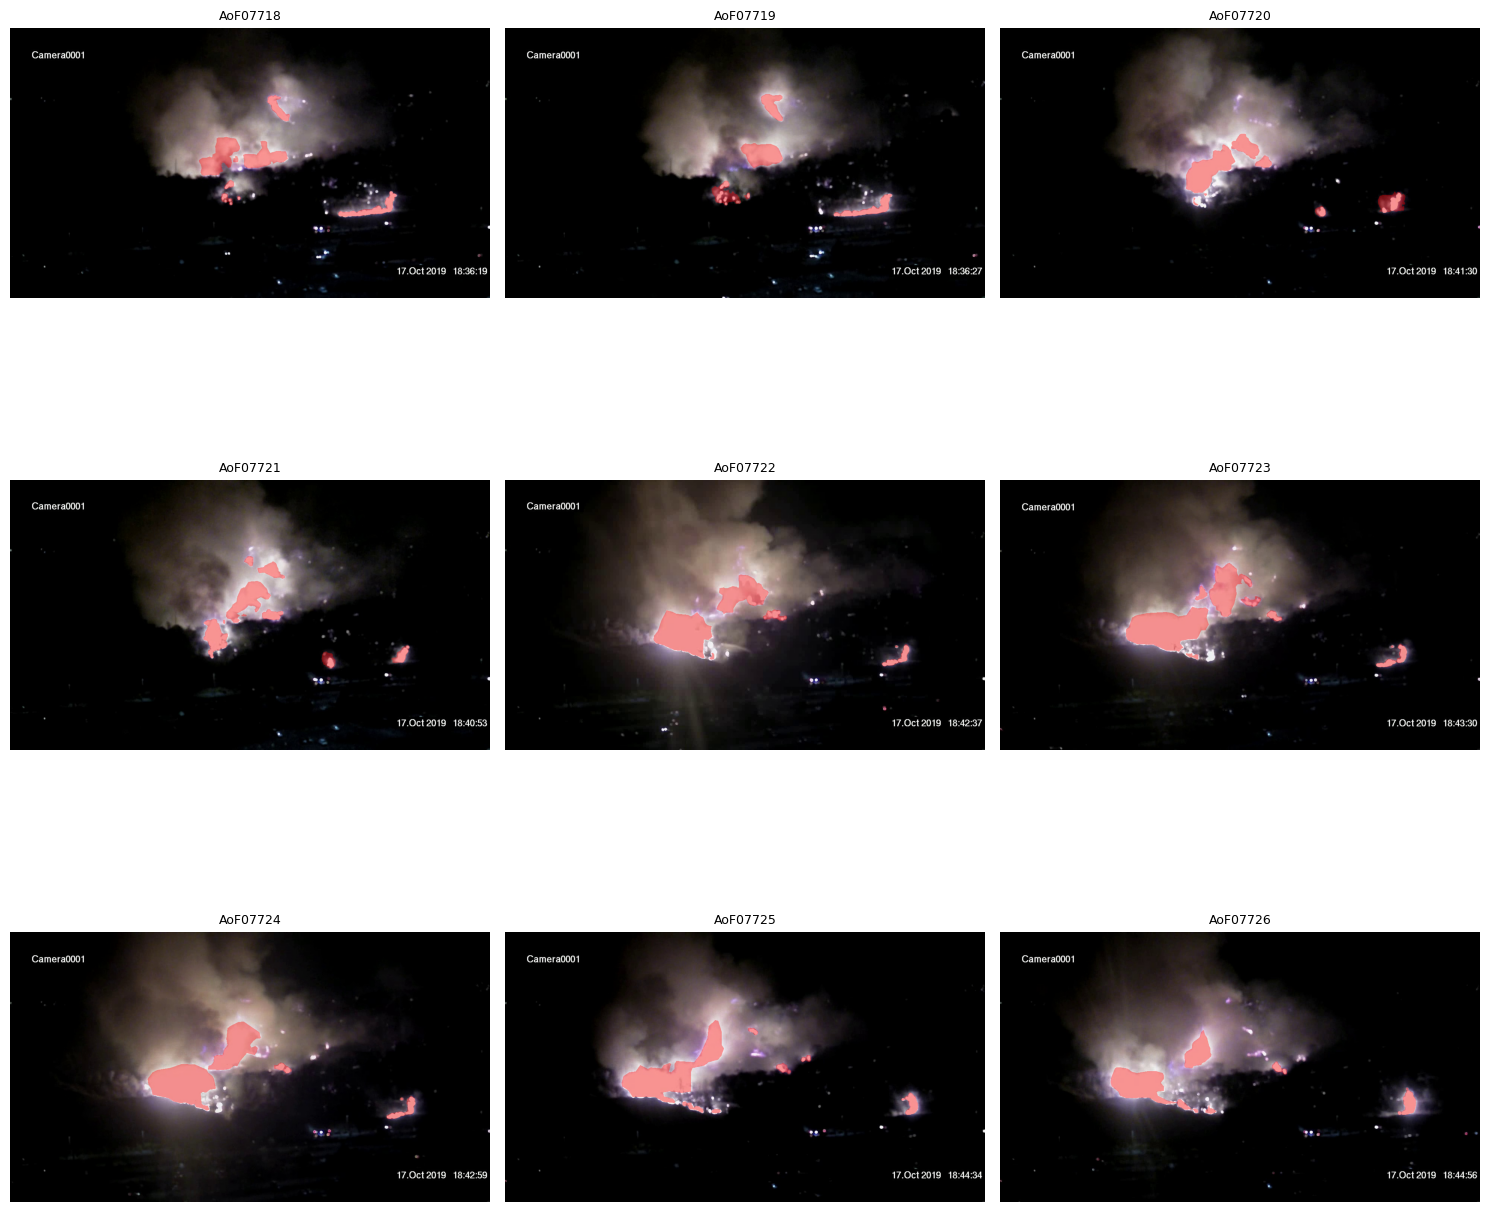

In [ ]:
# CELDA 4: Inspección visual — CRÍTICO antes de escalar a las 5822 imágenes completas
from verificar_mascaras_sam import visualizar_muestras
visualizar_muestras("/content/dfire_yolo_seg", n_muestras=9)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

directorio_salida = "/content/drive/MyDrive/dfire_yolo_seg"

Mounted at /content/drive


In [ ]:
from dfire_sam_to_yolo_seg import cargar_modelo_sam, procesar_dataset_dfire

predictor = cargar_modelo_sam(checkpoint_path="/content/sam_vit_b_01ec64.pth")

procesar_dataset_dfire(
    directorio_dfire=ruta_dfire,
    directorio_salida=directorio_salida,
    predictor=predictor,
    max_imagenes=None,  # procesa las 5822 completas
)

SAM (vit_b) cargado en: cuda
Procesadas: 50 | Omitidas: 0 | Ya existían: 0
Procesadas: 100 | Omitidas: 0 | Ya existían: 0
Procesadas: 150 | Omitidas: 0 | Ya existían: 0
Procesadas: 200 | Omitidas: 0 | Ya existían: 0
Procesadas: 250 | Omitidas: 0 | Ya existían: 0
Procesadas: 300 | Omitidas: 0 | Ya existían: 0
Procesadas: 350 | Omitidas: 0 | Ya existían: 0
Procesadas: 400 | Omitidas: 0 | Ya existían: 0
Procesadas: 450 | Omitidas: 0 | Ya existían: 0
Procesadas: 500 | Omitidas: 0 | Ya existían: 0
Procesadas: 550 | Omitidas: 0 | Ya existían: 0
Procesadas: 600 | Omitidas: 0 | Ya existían: 0
Procesadas: 650 | Omitidas: 0 | Ya existían: 0
Procesadas: 700 | Omitidas: 0 | Ya existían: 0
Procesadas: 750 | Omitidas: 0 | Ya existían: 0
Procesadas: 800 | Omitidas: 0 | Ya existían: 0
Procesadas: 850 | Omitidas: 0 | Ya existían: 0
Procesadas: 900 | Omitidas: 0 | Ya existían: 0
Procesadas: 950 | Omitidas: 0 | Ya existían: 0
Procesadas: 1000 | Omitidas: 0 | Ya existían: 0
Procesadas: 1050 | Omitidas: 0 

Extraer dataser de roboflow

In [ ]:
!pip install -q roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="TU_API_KEY_AQUI")
project = rf.workspace("manuela-mayorga-rojas").project("fire-and-smoke-segmentation-3zmty")
dataset = project.version(1).download("yolov8")
print(dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 148.0 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-and-Smoke-Segmentation-1 in yolov8:: 100%|██████████| 407/407 [00:00<00:00, 8756.87it/s]

/content/Fire-and-Smoke-Segmentation-1


Combinar dataset

In [ ]:
from combinar_datasets_firequant import combinar_datasets

combinar_datasets(
    directorio_roboflow=dataset.location,
    directorio_dfire_sam="/content/drive/MyDrive/dfire_yolo_seg",
    directorio_salida="/content/drive/MyDrive/firequant_dataset_v2",
)

Roboflow -> train: 141 pares copiados
Roboflow -> valid: 40 pares copiados
Roboflow -> test: 20 pares copiados
D-Fire+SAM -> train: 4075 pares copiados
D-Fire+SAM -> valid: 1164 pares copiados
D-Fire+SAM -> test: 583 pares copiados

Dataset combinado generado en: /content/drive/MyDrive/firequant_dataset_v2
Total Roboflow: 201 | Total D-Fire+SAM: 5822 | Total combinado: 6023
data.yaml generado en: /content/drive/MyDrive/firequant_dataset_v2/data.yaml


Entrenamiento de modelo

In [ ]:

from train_firequant_yolo26 import verificar_entorno, entrenar_modelo, validar_modelo

verificar_entorno()

modelo = entrenar_modelo(
    data_yaml="/content/drive/MyDrive/firequant_dataset_v2/data.yaml",
    epochs=60,
    batch=48,
    cache="ram",
    nombre_experimento="yolo26n_seg_v2_combinado",
)

GPU detectada: NVIDIA L4
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/firequant_dataset_v2/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_seg_v2_combinado, nbs=64, nms=False, ops

Correr solo resultados

In [ ]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import files
import os

os.makedirs('/content/imagenes_prueba', exist_ok=True)
subidas = files.upload()

for nombre in subidas:
    os.rename(nombre, f'/content/imagenes_prueba/{nombre}')

Saving image1.jpg to image1.jpg
Saving image2.jpg to image2.jpg
Saving image3.jpg to image3.jpg
Saving image4.jpg to image4.jpg
Saving image5.jpg to image5.jpg
Saving image6.jpg to image6.jpg
Saving image7.jpg to image7.jpg
Saving image8.jpg to image8.jpg
Saving image9.jpg to image9.jpg
Saving image10.jpg to image10.jpg
Saving image11.jpg to image11.jpg
Saving image12.jpg to image12.jpg
Saving image13.jpg to image13.jpg
Saving image14.jpg to image14.jpg
Saving image15.jpg to image15.jpg
Saving image16.jpg to image16.jpg
Saving image17.jpg to image17.jpg
Saving image18.jpg to image18.jpg


In [ ]:
from procesar_lote_prueba import procesar_lote

resumen_final = procesar_lote(
    weights_path="/content/drive/MyDrive/FireQuant_runs/yolo26n_seg_v2_combinado/weights/best.pt",
    carpeta_imagenes="/content/imagenes_prueba",
    carpeta_salida_anotadas="/content/imagenes_prueba_FINAL",
    conf_threshold=0.15,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imagen                   FP (%)    Nivel       Instancias  
------------------------------------------------------------
image1.jpg               0.41      Low         2           
image10.jpg              0.44      Low         4           
image11.jpg              3.58      Medium      1           
image12.jpg              54.72     Critical    2           
image13.jpg              6.67      Medium      5           
image14.jpg              2.23      Low         9           
image15.jpg              5.93      Medium      5           
image16.jpg              20.32     High        5           
image17.jpg              1.07      Low         2           
image18.jpg              5.2

In [ ]:
import shutil
shutil.make_archive('/content/imagenes_prueba_FINAL', 'zip', '/content/imagenes_prueba_FINAL')

from google.colab import files
files.download('/content/imagenes_prueba_FINAL.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Resultados

In [ ]:
!ls /content/drive/MyDrive/FireQuant_runs/yolo26n_seg_v2_combinado/

args.yaml			 MaskP_curve.png      train_batch4301.jpg
BoxF1_curve.png			 MaskPR_curve.png     train_batch4302.jpg
BoxP_curve.png			 MaskR_curve.png      val_batch0_labels.jpg
BoxPR_curve.png			 results.csv	      val_batch0_pred.jpg
BoxR_curve.png			 results.png	      val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch0.jpg     val_batch1_pred.jpg
confusion_matrix.png		 train_batch1.jpg     val_batch2_labels.jpg
labels.jpg			 train_batch2.jpg     val_batch2_pred.jpg
MaskF1_curve.png		 train_batch4300.jpg  weights


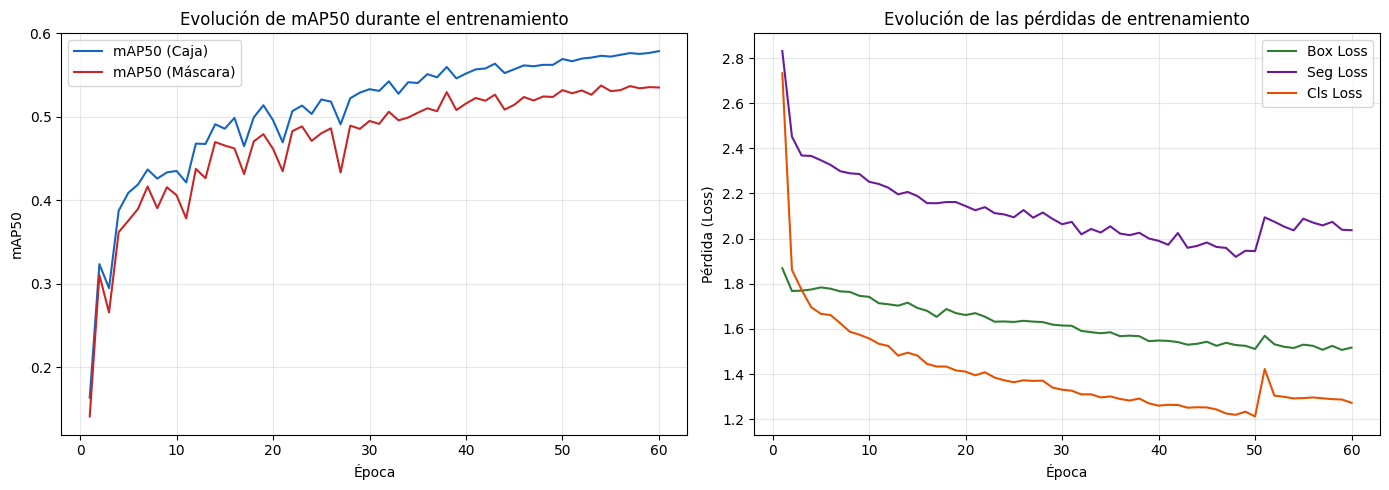

Gráfica guardada en: evolucion_entrenamiento.png
=== Métricas finales del entrenamiento ===
train/box_loss                : 1.5172
train/seg_loss                : 2.0372
train/cls_loss                : 1.2727
train/dfl_loss                : 0.0051
train/sem_loss                : 0.8020
metrics/precision(B)          : 0.6439
metrics/recall(B)             : 0.5367
metrics/mAP50(B)              : 0.5787
metrics/mAP50-95(B)           : 0.3571
metrics/precision(M)          : 0.6464
metrics/recall(M)             : 0.4940
metrics/mAP50(M)              : 0.5351
metrics/mAP50-95(M)           : 0.2708
val/box_loss                  : 1.5070
val/seg_loss                  : 2.1655
val/cls_loss                  : 1.3273
val/dfl_loss                  : 0.0064
val/sem_loss                  : 0.0000
Imagen                   FP (%)    Nivel       Instancias  
------------------------------------------------------------
image1.jpg               0.41      Low         2           
image10.jpg              

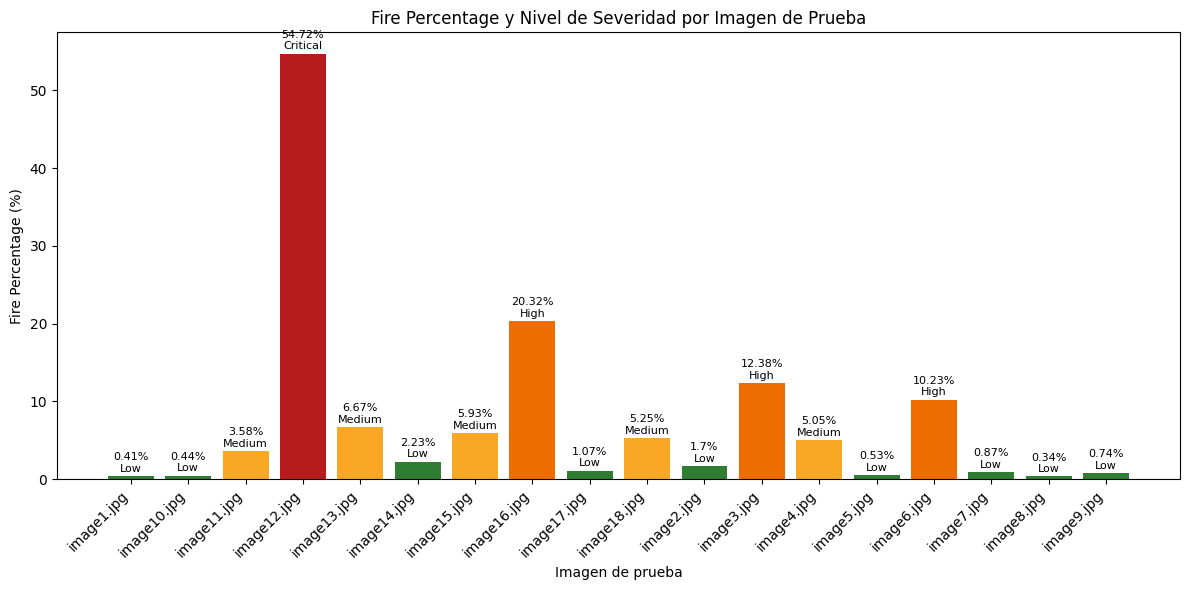

Gráfica guardada en: fire_percentage_por_imagen.png


In [ ]:
from generar_graficas_resultados import (
    graficar_evolucion_entrenamiento,
    graficar_fire_percentage_por_imagen,
    imprimir_tabla_metricas_finales,
)

RUTA_RUN = "/content/drive/MyDrive/FireQuant_runs/yolo26n_seg_v2_combinado"

# 1. Curvas de entrenamiento (mAP y pérdidas por época)
graficar_evolucion_entrenamiento(RUTA_RUN)

# 2. Tabla de métricas finales (para copiar directo al paper)
imprimir_tabla_metricas_finales(RUTA_RUN)

# 3. Gráfica de FP por imagen de prueba (usa el resumen que ya generaste)
from procesar_lote_prueba import procesar_lote
resumen = procesar_lote(
    weights_path=f"{RUTA_RUN}/weights/best.pt",
    carpeta_imagenes="/content/imagenes_prueba",
    carpeta_salida_anotadas="/content/imagenes_prueba_FINAL",
    conf_threshold=0.15,
)
graficar_fire_percentage_por_imagen(resumen)